In [1]:
import os
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, models, transforms
from sklearn.model_selection import train_test_split

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [3]:
import kagglehub

path = "nirmalsankalana/plant-diseases-training-dataset"
Dataset_path = kagglehub.dataset_download(path)
ChackPoint_path = '/content/models/model_checkpoint.pth'

Using Colab cache for faster access to the 'plant-diseases-training-dataset' dataset.


In [4]:
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
])

Dataset = datasets.ImageFolder(root = Dataset_path + "/data", transform= transform)
class_names = Dataset.classes
# Dataset = datasets.ImageFolder(
#     root=Dataset_path,
#     transform=transform,
#     is_valid_file=lambda x: 'Apple' in x
# )

In [5]:
# Dataset.classes = [c for c in os.listdir(Dataset_path+'/data') if c.startswith('Apple')]
# Dataset.class_to_idx = {cls: i for i, cls in enumerate(sorted(Dataset.classes))}

# class_names = Dataset.classes

In [6]:
class_names

['Apple___alternaria_leaf_spot',
 'Apple___black_rot',
 'Apple___brown_spot',
 'Apple___gray_spot',
 'Apple___healthy',
 'Apple___rust',
 'Apple___scab',
 'Bell_pepper___bacterial_spot',
 'Bell_pepper___healthy',
 'Blueberry___healthy',
 'Cassava___bacterial_blight',
 'Cassava___brown_streak_disease',
 'Cassava___green_mottle',
 'Cassava___healthy',
 'Cassava___mosaic_disease',
 'Cherry___healthy',
 'Cherry___powdery_mildew',
 'Coffee___healthy',
 'Coffee___red_spider_mite',
 'Coffee___rust',
 'Corn___common_rust',
 'Corn___gray_leaf_spot',
 'Corn___healthy',
 'Corn___northern_leaf_blight',
 'Grape___Leaf_blight',
 'Grape___black_measles',
 'Grape___black_rot',
 'Grape___healthy',
 'Grape___leaf_blight',
 'Orange___citrus_greening',
 'Peach___bacterial_spot',
 'Peach___healthy',
 'Potato___bacterial_wilt',
 'Potato___early_blight',
 'Potato___healthy',
 'Potato___late_blight',
 'Potato___leafroll_virus',
 'Potato___mosaic_virus',
 'Potato___nematode',
 'Potato___pests',
 'Potato___phyt

Visualizing some sample images from the dataset...


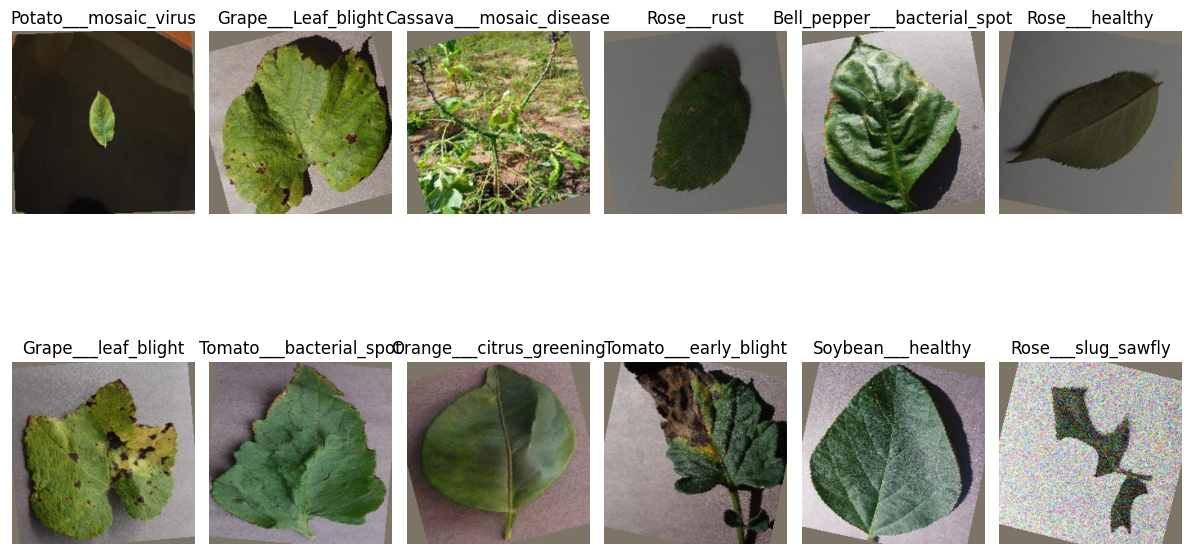

In [7]:
def visualize_data(dataset, class_names, num_images=12):
    figure = plt.figure(figsize=(12,8))
    indices = np.random.choice(len(dataset), num_images, replace = False)
    for i, idx in enumerate(indices):
        ax = figure.add_subplot(2, num_images // 2, i + 1)
        image, label = dataset[idx]
        ax.imshow(np.transpose(image.numpy(), (1, 2, 0)) * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406]))
        ax.set_title(class_names[label])
        ax.axis('off')
    plt.tight_layout()
    plt.show()

print("Visualizing some sample images from the dataset...")
visualize_data(Dataset, class_names)

In [8]:
train_size = int(0.7 * len(Dataset))
val_size = int(0.2 * len(Dataset))
test_size = len(Dataset) - train_size - val_size
train_dataset, val_dataset, test_dataset = torch.utils.data.random_split(
    Dataset, [train_size, val_size, test_size]
)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)


In [9]:
print(f"Number of training samples: {len(train_dataset)}")
print(f"Number of validation samples: {len(val_dataset)}")
print(f"Number of testing samples: {len(test_dataset)}")

print("Class Names:")
for idx, class_name in enumerate(class_names):
    print(f"{idx}: {class_name}")


Number of training samples: 81302
Number of validation samples: 23229
Number of testing samples: 11616
Class Names:
0: Apple___alternaria_leaf_spot
1: Apple___black_rot
2: Apple___brown_spot
3: Apple___gray_spot
4: Apple___healthy
5: Apple___rust
6: Apple___scab
7: Bell_pepper___bacterial_spot
8: Bell_pepper___healthy
9: Blueberry___healthy
10: Cassava___bacterial_blight
11: Cassava___brown_streak_disease
12: Cassava___green_mottle
13: Cassava___healthy
14: Cassava___mosaic_disease
15: Cherry___healthy
16: Cherry___powdery_mildew
17: Coffee___healthy
18: Coffee___red_spider_mite
19: Coffee___rust
20: Corn___common_rust
21: Corn___gray_leaf_spot
22: Corn___healthy
23: Corn___northern_leaf_blight
24: Grape___Leaf_blight
25: Grape___black_measles
26: Grape___black_rot
27: Grape___healthy
28: Grape___leaf_blight
29: Orange___citrus_greening
30: Peach___bacterial_spot
31: Peach___healthy
32: Potato___bacterial_wilt
33: Potato___early_blight
34: Potato___healthy
35: Potato___late_blight
36: 

In [10]:
model = models.resnet50(pretrained = True)
for param in model.parameters():
    param.requires_grad = False

num_features = model.fc.in_features
model.fc = nn.Linear(num_features, len(class_names))
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.fc.parameters(), lr=0.001)


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [11]:
def save_checkpoint(epoch, model, optimizer, val_loss):
    checkpoint = {
        'epoch' : epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'val_loss': val_loss,
    }
    torch.save(checkpoint,ChackPoint_path)

def load_checkpoint():
    if os.path.exists(ChackPoint_path):
        checkpoint = torch.load(ChackPoint_path, map_location=device)
        model.load_state_dict(checkpoint['model_state_dict'])
        optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
        start_epoch = checkpoint['epoch'] + 1
        val_loss = checkpoint['val_loss']
        print(f"Resumed training from epoch {start_epoch}")
        return start_epoch, val_loss
    return 0, float('inf')

start_epoch, best_val_loss = load_checkpoint()

In [12]:
from tqdm import tqdm
import torch

def train_model(
    model,
    train_loader,
    valid_loader,
    criterion,
    optimizer,
    num_epochs=5,
    start_epoch=0,
    # checkpoint_path="model_checkpoint.pth",
    checkpoint_path= ChackPoint_path,
    device='cuda'
):

    model = model.to(device)

    for epoch in range(start_epoch, num_epochs):
        print(f"Epoch {epoch + 1}/{num_epochs}")
        print('-' * 30)

        # Training Phase
        model.train()
        train_loss = 0.0
        correct = 0
        total = 0

        for images, labels in tqdm(train_loader, desc="Training"):
            images, labels = images.to(device), labels.to(device)

            # Forward pass
            outputs = model(images)
            loss = criterion(outputs, labels)

            # Backward pass and optimization
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            # Accumulate metrics
            train_loss += loss.item()
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

        epoch_loss = train_loss / len(train_loader)
        epoch_acc = correct / total
        print(f"Train Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}")

        # Validation Phase
        model.eval()
        valid_loss = 0.0
        valid_correct = 0
        valid_total = 0

        with torch.no_grad():
            for images, labels in tqdm(valid_loader, desc="Validation"):
                images, labels = images.to(device), labels.to(device)

                # Forward pass
                outputs = model(images)
                loss = criterion(outputs, labels)

                # Accumulate metrics
                valid_loss += loss.item()
                _, preds = torch.max(outputs, 1)
                valid_correct += (preds == labels).sum().item()
                valid_total += labels.size(0)

        valid_loss /= len(valid_loader)
        valid_acc = valid_correct / valid_total
        print(f"Validation Loss: {valid_loss:.4f} Acc: {valid_acc:.4f}")

        # Save checkpoint
        checkpoint = {
            'epoch': epoch + 1,  # Save the next epoch to resume from
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict()
        }
        torch.save(checkpoint, checkpoint_path)
        print(f"Checkpoint saved at epoch {epoch + 1} to {checkpoint_path}\n")

    print("Training complete.")
    return model


In [13]:
# Train the model
trained_model = train_model(
    model=model,
    train_loader=train_loader,
    valid_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    num_epochs=5,
    checkpoint_path="/content/models/plant_disease_resnet50_checkpoint.pth",
    device=device
)


Epoch 1/5
------------------------------


Training: 100%|██████████| 2541/2541 [12:22<00:00,  3.42it/s]


Train Loss: 0.6728 Acc: 0.8064


Validation: 100%|██████████| 726/726 [03:26<00:00,  3.51it/s]


Validation Loss: 0.4314 Acc: 0.8591
Checkpoint saved at epoch 1 to /content/models/plant_disease_resnet50_checkpoint.pth

Epoch 2/5
------------------------------


...

Validation Loss: 0.3352 Acc: 0.8940
Checkpoint saved at epoch 4 to /content/models/plant_disease_resnet50_checkpoint.pth

Epoch 5/5
------------------------------


Training: 100%|██████████| 2541/2541 [12:05<00:00,  3.50it/s]


Train Loss: 0.3574 Acc: 0.8825


Validation: 100%|██████████| 726/726 [03:21<00:00,  3.60it/s]


Validation Loss: 0.3240 Acc: 0.8965
Checkpoint saved at epoch 5 to /content/models/plant_disease_resnet50_checkpoint.pth

Training complete.


In [14]:
def test_model(model, test_loader, device='cuda'):

    model.eval()  # Set model to evaluation mode
    test_loss = 0.0
    correct = 0
    total = 0

    criterion = nn.CrossEntropyLoss()  # Define loss for evaluation

    with torch.no_grad():
        for images, labels in tqdm(test_loader, desc="Testing"):
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)
            test_loss += loss.item()

            # Calculate accuracy
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    test_loss /= len(test_loader)
    test_accuracy = correct / total
    print(f"Test Loss: {test_loss:.4f}, Test Accuracy: {test_accuracy:.4f}")

    return test_loss, test_accuracy



In [15]:
model.to(device)
test_loss, test_accuracy = test_model(model, test_loader, device=device)

Testing: 100%|██████████| 363/363 [01:45<00:00,  3.43it/s]

Test Loss: 0.3324, Test Accuracy: 0.8947


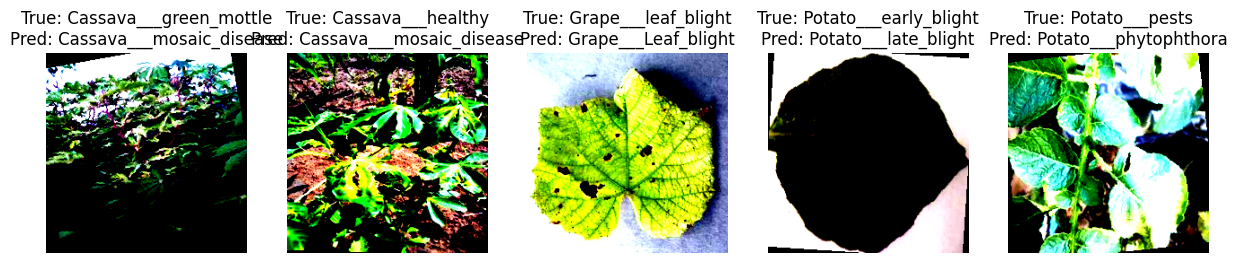

In [16]:
import matplotlib.pyplot as plt

def visualize_misclassified(model, test_loader, class_names, device='cuda'):
    model.eval()
    misclassified_images = []
    misclassified_labels = []
    misclassified_preds = []

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)

            for i in range(len(labels)):
                if preds[i] != labels[i]:
                    misclassified_images.append(images[i].cpu())
                    misclassified_labels.append(labels[i].item())
                    misclassified_preds.append(preds[i].item())

    # Plot a few misclassified images
    fig, axes = plt.subplots(1, 5, figsize=(15, 5))
    for i, ax in enumerate(axes):
        if i < len(misclassified_images):
            img = misclassified_images[i].permute(1, 2, 0)  # CHW to HWC
            ax.imshow(img)
            ax.axis('off')
            true_label = class_names[misclassified_labels[i]]
            pred_label = class_names[misclassified_preds[i]]
            ax.set_title(f"True: {true_label}\nPred: {pred_label}")
    plt.show()

visualize_misclassified(model, test_loader, class_names, device=device)


In [17]:
torch.save(model, "/content/models/plant_disease_classifier_full.pth")

print("Full model saved as plant_disease_classifier_full.pth")


Full model saved as plant_disease_classifier_full.pth


In [18]:
assert os.path.exists("/content/models/plant_disease_classifier_full.pth"), "Model file not saved!"
print("Model saved successfully!")


Model saved successfully!


In [20]:
model = torch.load("/content/models/plant_disease_classifier_full.pth", weights_only= False)
model.to(device)
model.eval()
print("Model loaded successfully!")

Model loaded successfully!


In [21]:
torch.save(model, "/content/models/plant_disease_classifier_full.pth")


In [22]:
torch.save(model.state_dict(), '/content/models/plant_disease_classifier_state_dict.pth')


In [23]:
assert os.path.exists("/content/models/plant_disease_classifier_full.pth"), "Model file not saved!"
print("Model saved successfully!")


Model saved successfully!


In [24]:
scripted_model = torch.jit.script(model)
scripted_model.save("/content/models/model.pt")

print("model exported")

model exported


In [25]:
print(model)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [26]:
import os
print("Model file exists:", os.path.exists("/content/models/model.pt"))


Model file exists: True
